# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
| Muhammad Azka Ananta Khairon             | 5054251004      |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [ ]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [ ]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

data = pd.read_csv('/content/WineQT.csv')

print("Jumlah baris dan kolom:", data.shape)
data.head()

Jumlah baris dan kolom: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
data_clean = data.drop(columns=['Id'])

data_clean.info()
data_clean.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
print("Baris duplikat :",(data_clean.duplicated().sum()))
print("Jumlah missing values:")
data_clean.isna().sum()

Baris duplikat : 125
Jumlah missing values:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
data_cleaned = data_clean.drop_duplicates()

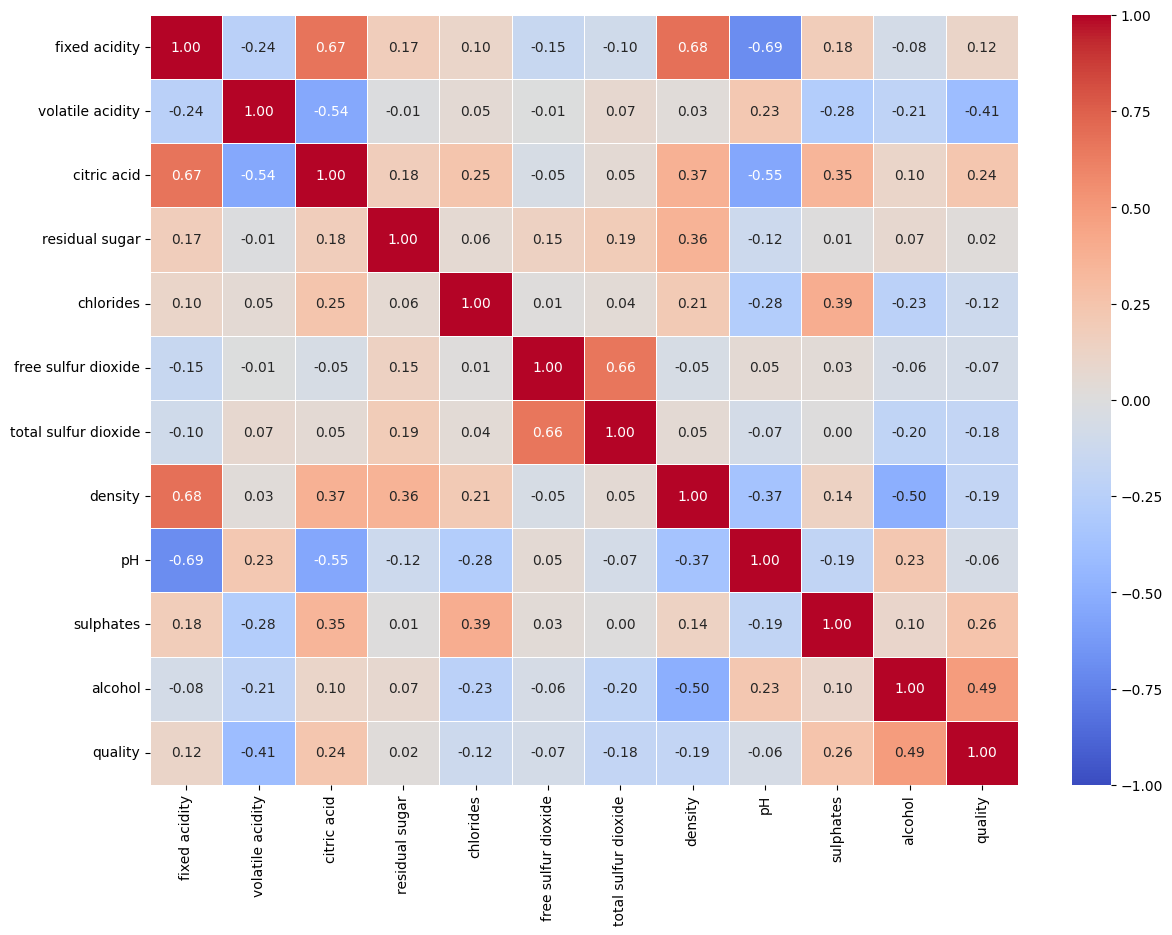

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(data_cleaned.corr(), cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, annot=True, fmt=".2f")
plt.show()

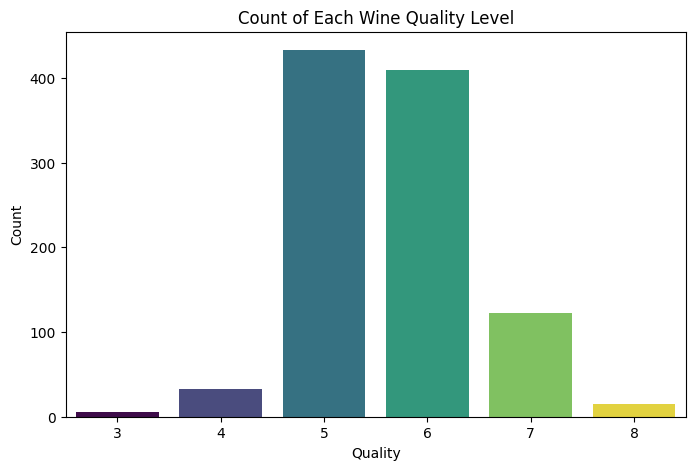

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', hue='quality', data=data_cleaned, palette='viridis', legend=False)
plt.title('Count of Each Wine Quality Level')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan.

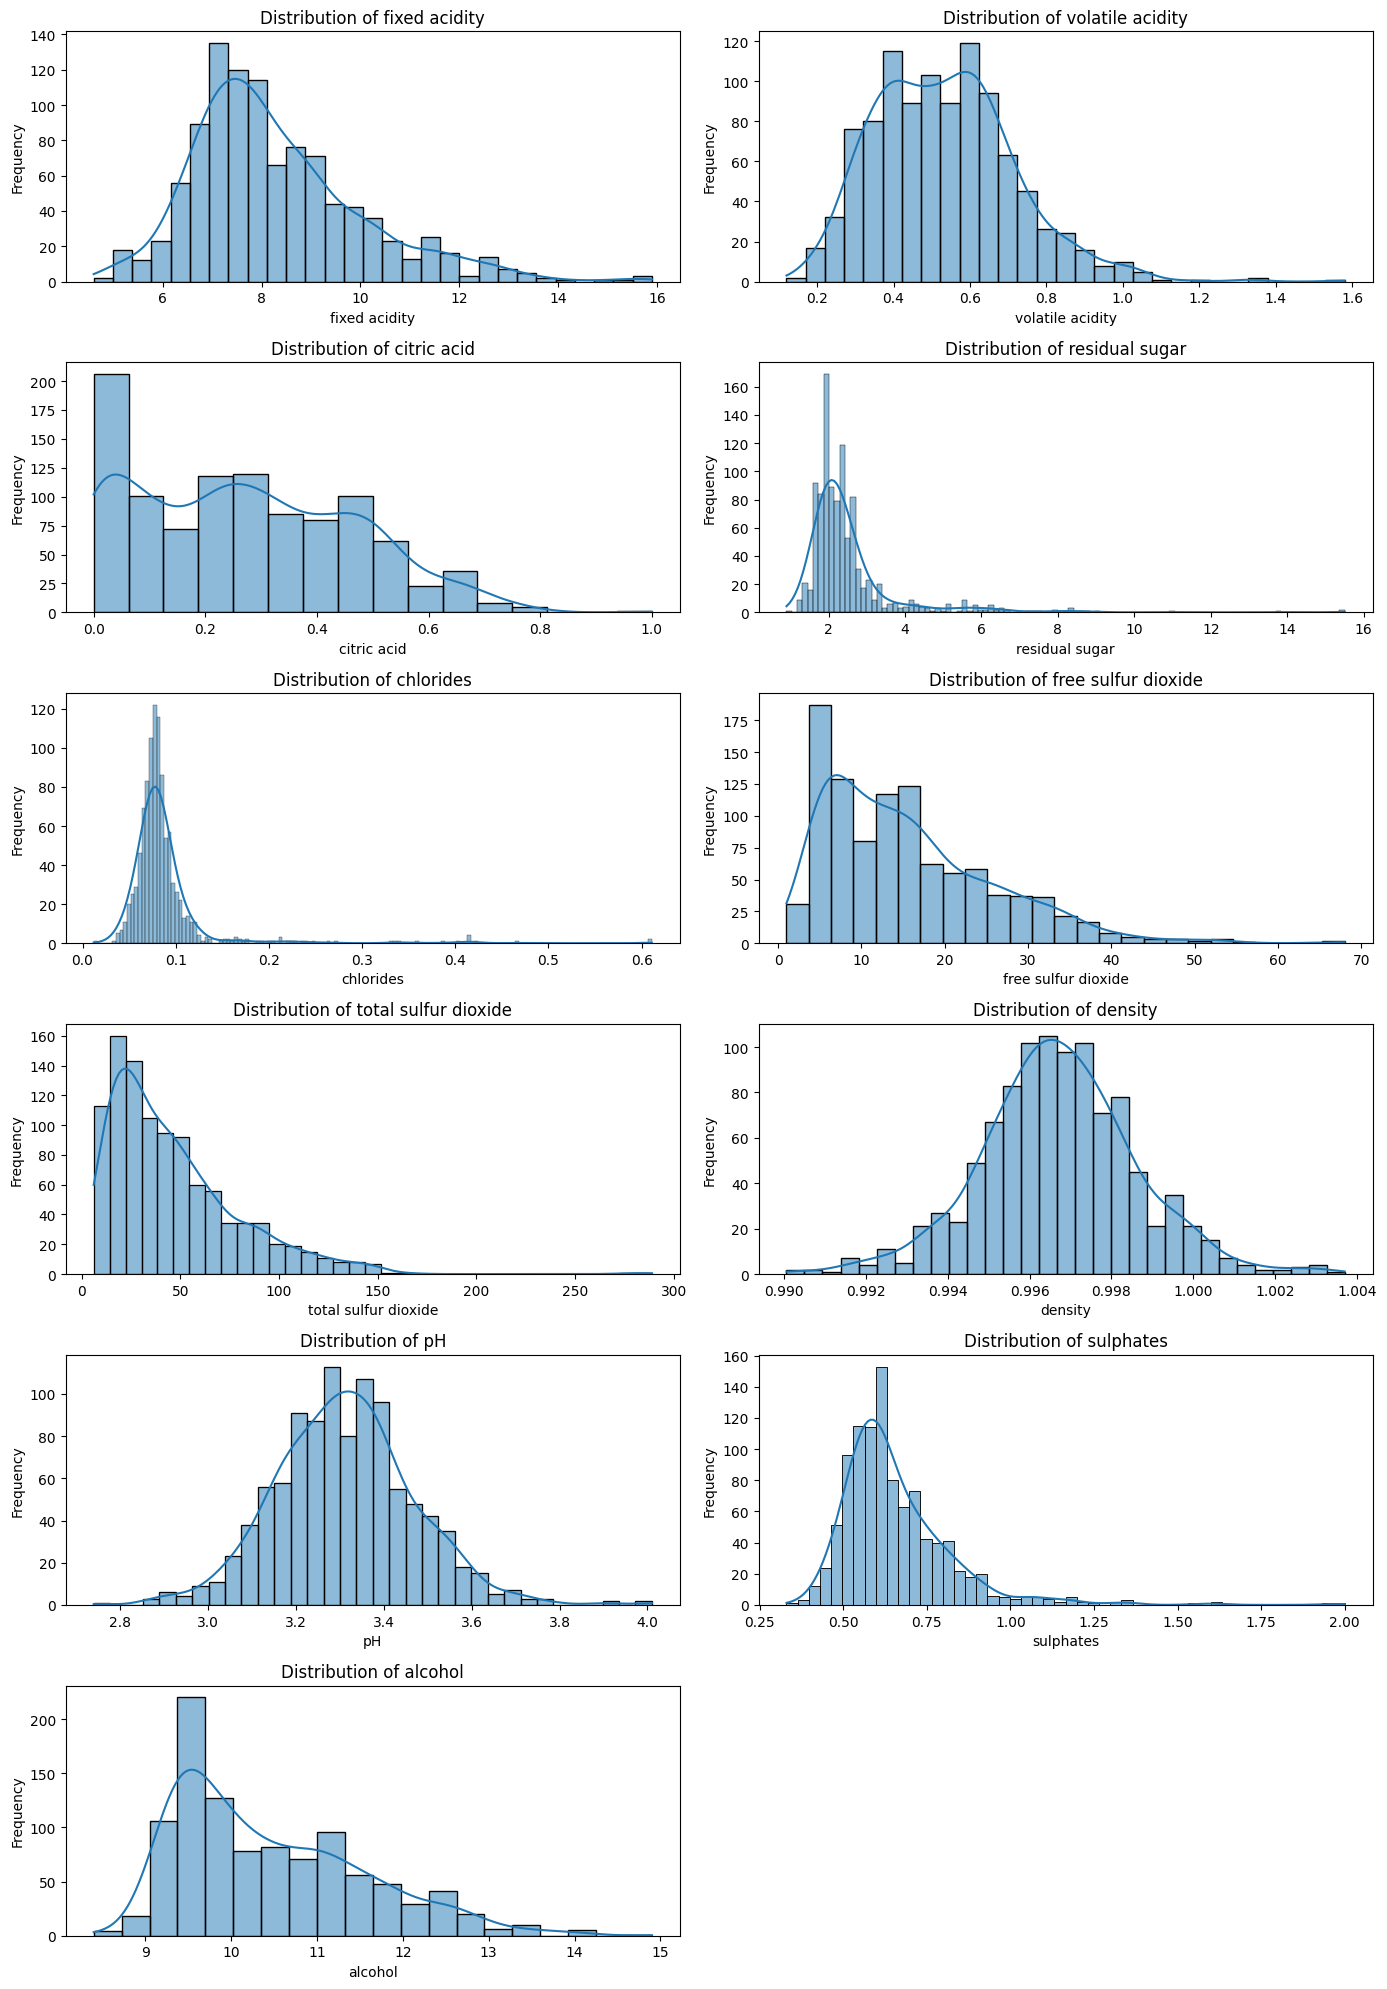

In [ ]:
data_features = data_cleaned.drop(columns=['quality'])

plt.figure(figsize=(14, 20))
for i, col in enumerate(data_features):
  plt.subplot(6, 2, i + 1)
  sns.histplot(data_features[col], kde=True)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

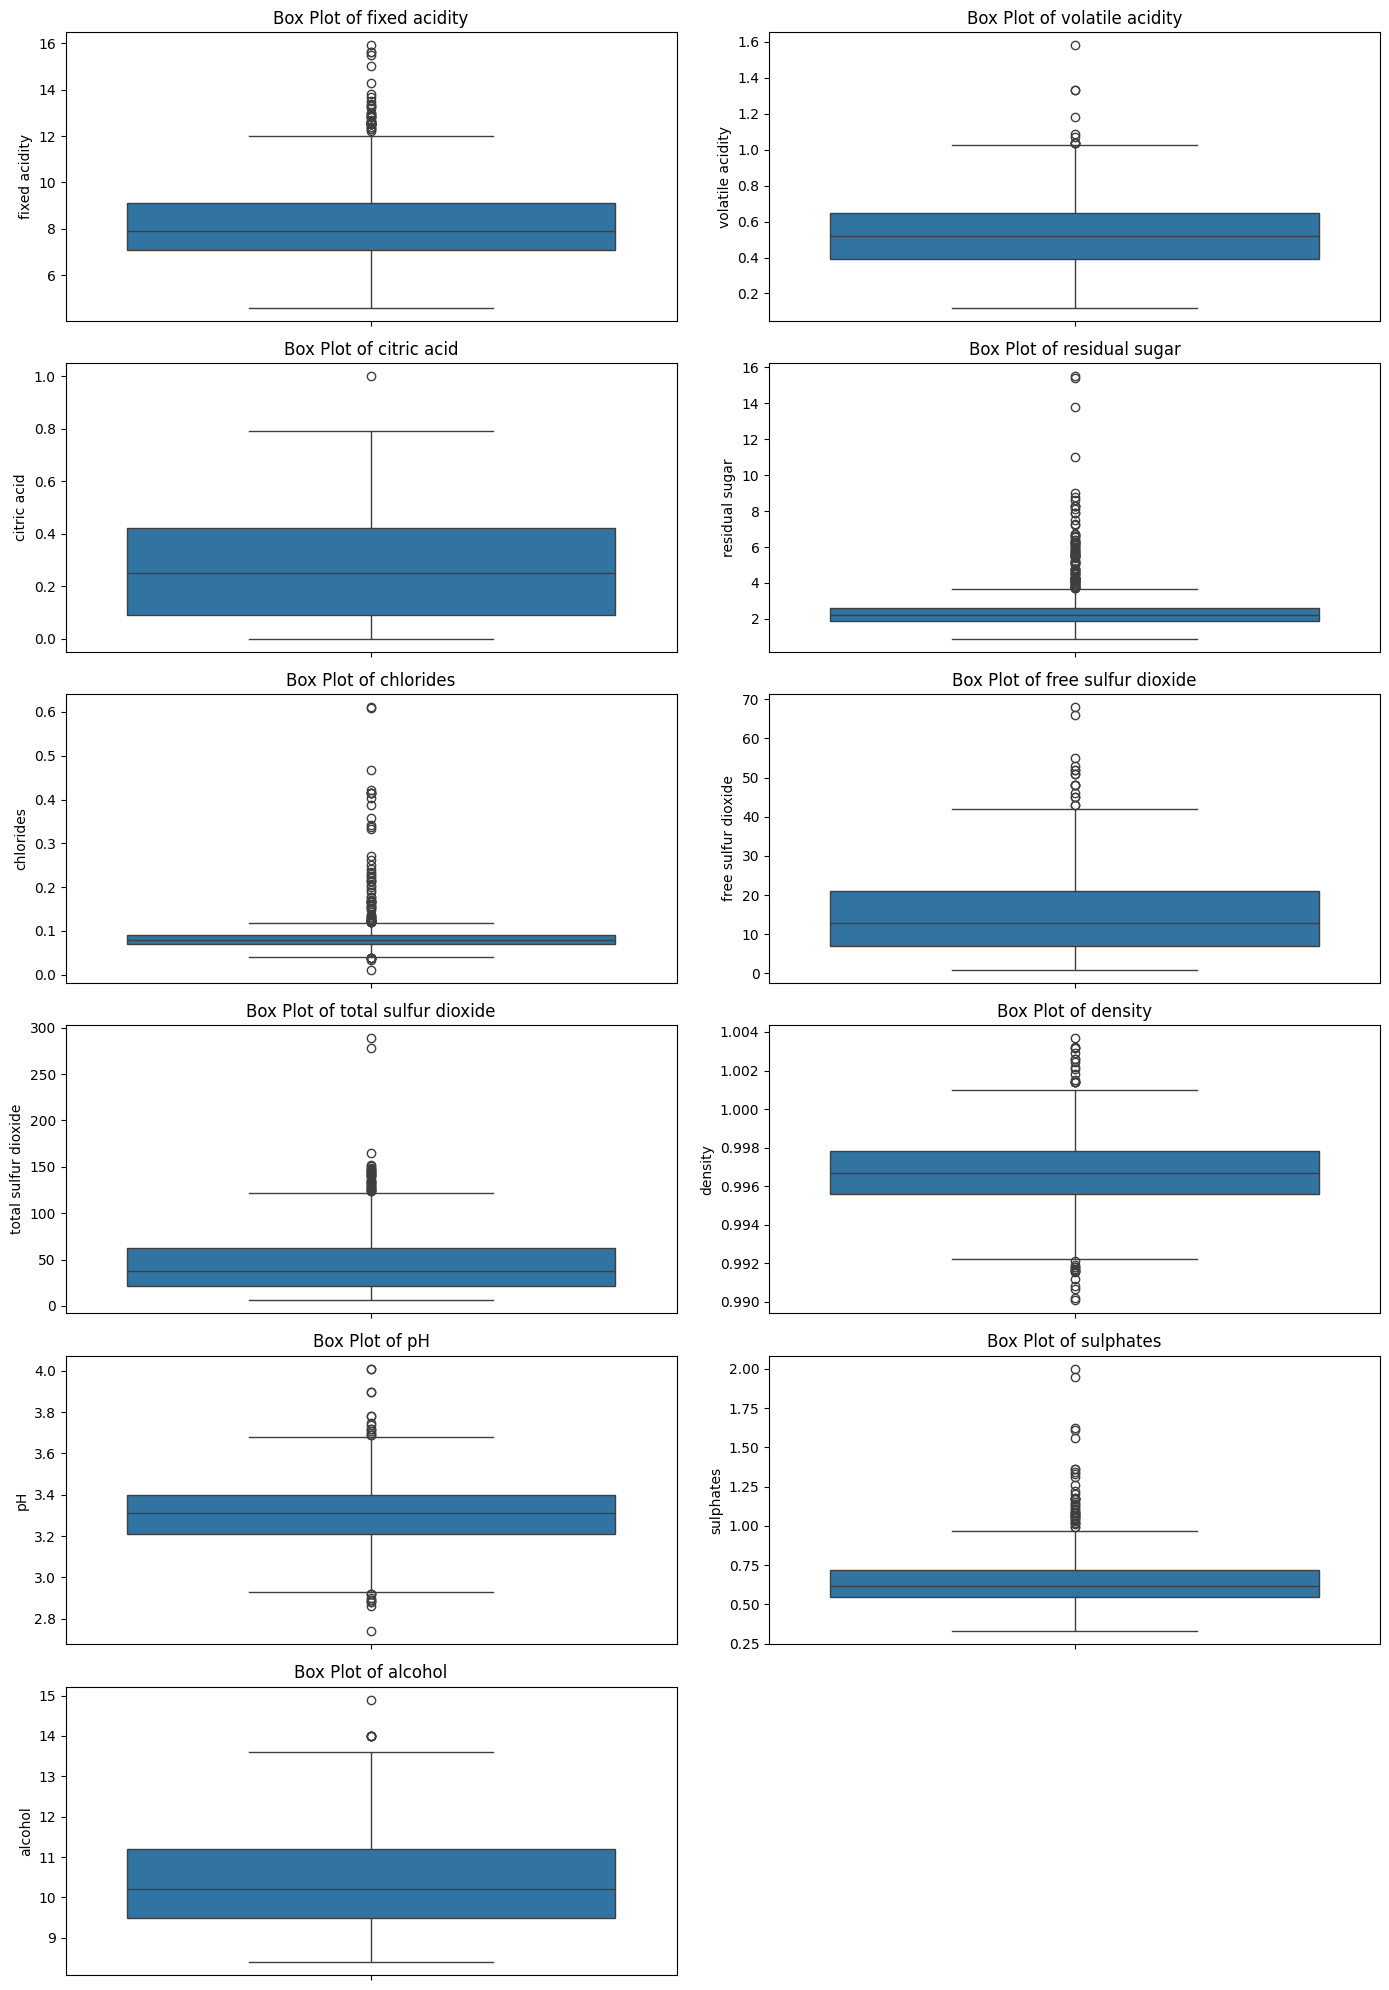

In [ ]:
plt.figure(figsize=(14, 20))
for i, col in enumerate(data_features):
  plt.subplot(6, 2, i + 1)
  sns.boxplot(y=data_features[col])
  plt.title(f'Box Plot of {col}')
  plt.ylabel(col)
plt.tight_layout()
plt.show()

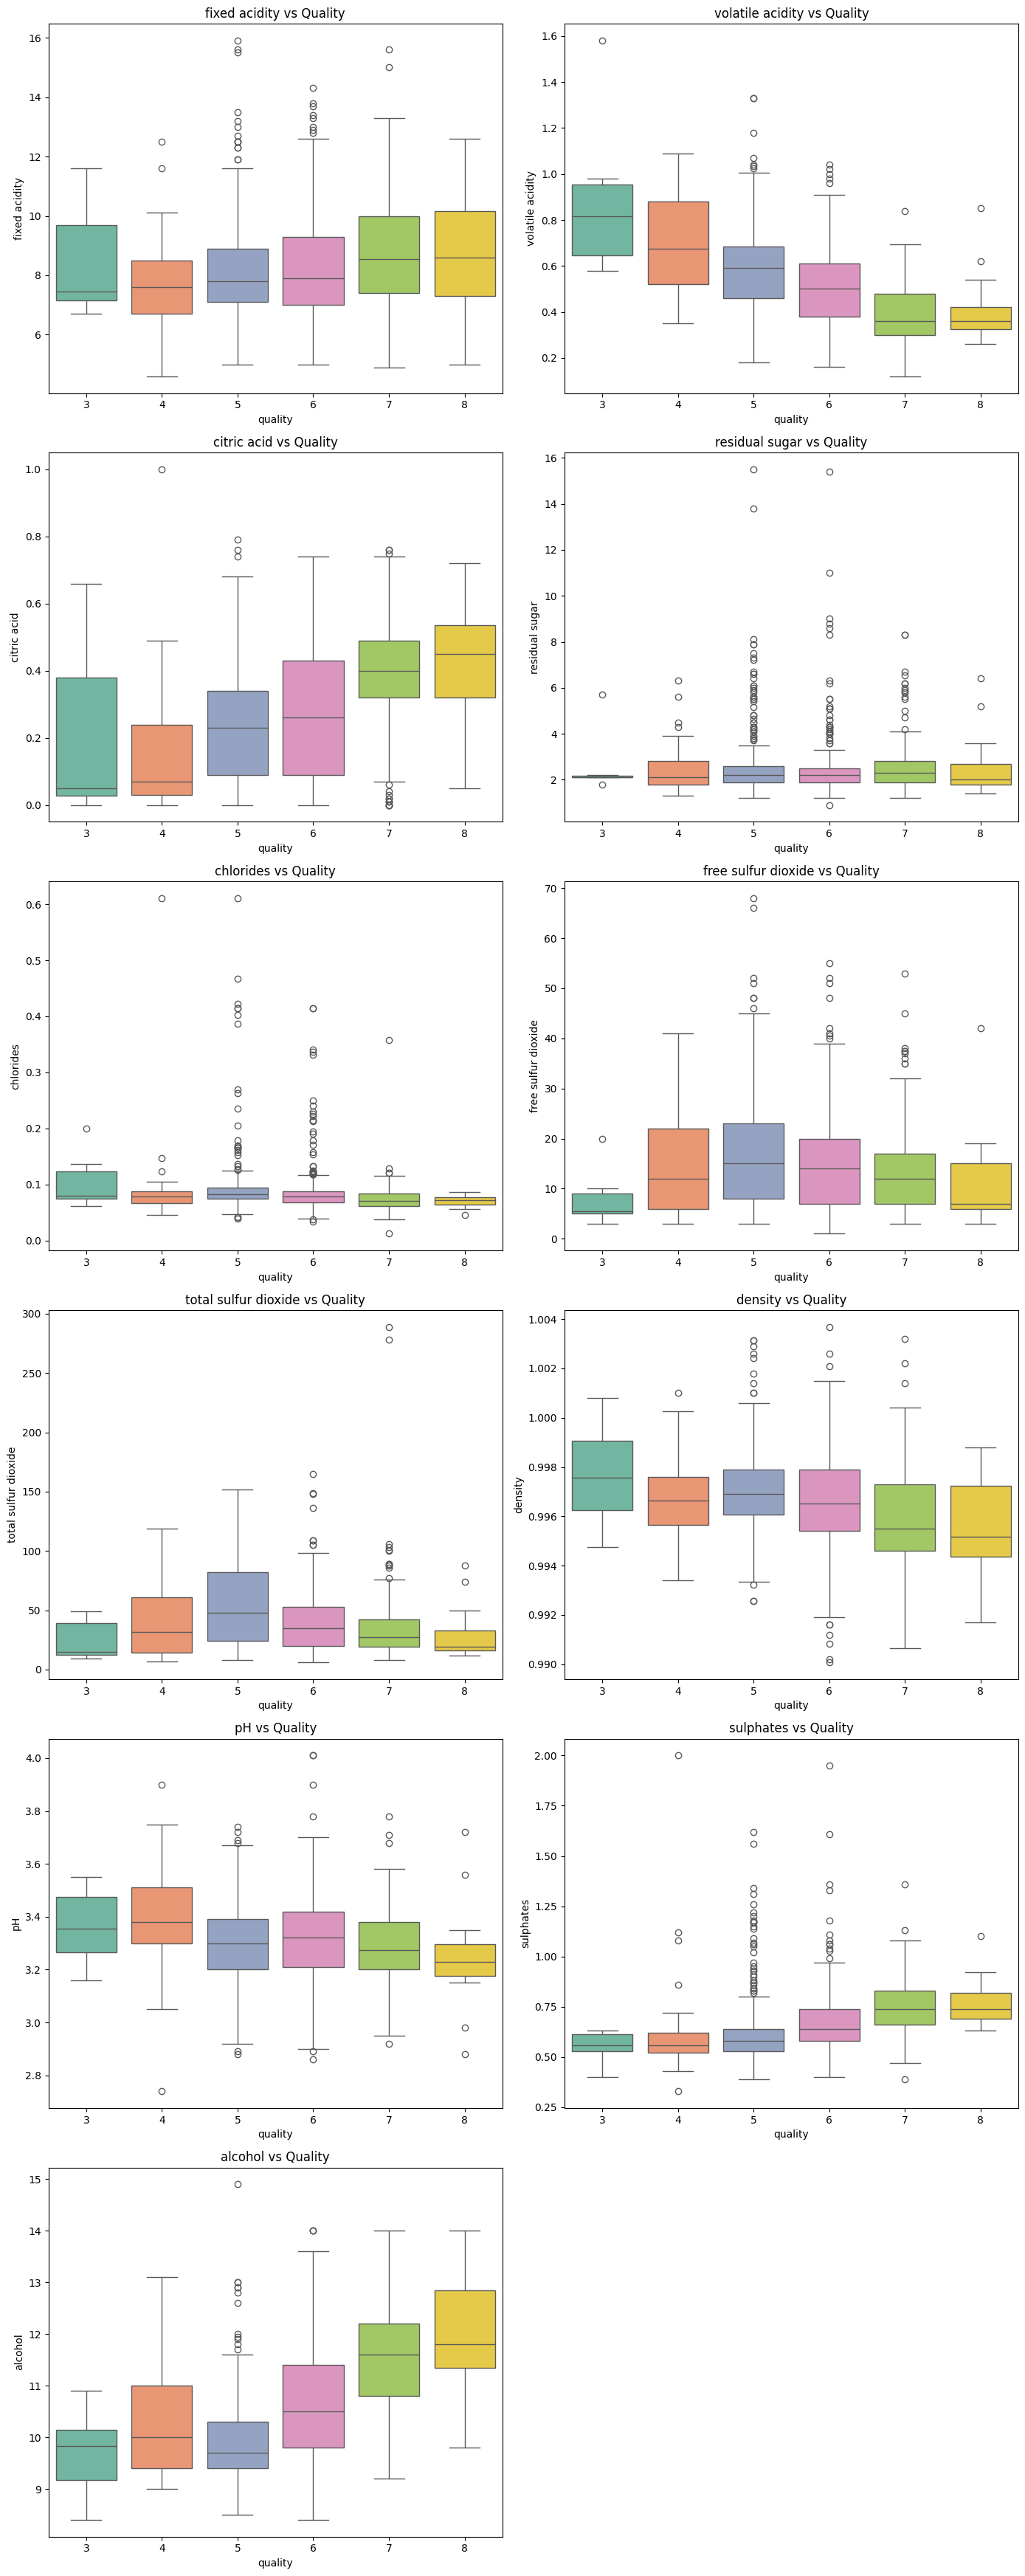

In [ ]:
plt.figure(figsize=(14, 35))
for i, col in enumerate(data_features):
  plt.subplot(6, 2, i + 1)
  sns.boxplot(data=data_cleaned, x="quality", y=col, hue="quality", palette="Set2", legend=False)
  plt.title(f"{col} vs Quality")
plt.tight_layout()
plt.show()

# 2. Preprocessing




In [ ]:
data_cleanclean = data_cleaned[data_cleaned['total sulfur dioxide'] <= 200].copy()
wine_data = data_cleanclean.drop(columns=["pH", "chlorides", "residual sugar"])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = wine_data.drop(columns=['quality'])
y = wine_data['quality']

x_train, x_test, y_train, y_test = train_test_split(
  x, y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

print(f"Ukuran x_train: {x_train.shape}")
print(f"Ukuran x_test : {x_test.shape}")

scaler = StandardScaler()

x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)

Ukuran x_train: (812, 8)
Ukuran x_test : (204, 8)


# 3. Eksperimen Model KNN


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

k_values = [k for k in range(1, 50) if k % 2 != 0]

weights_list = ['uniform', 'distance']
metrics_list = ['euclidean', 'manhattan']

results = []
best_f1 = 0
best_params = {}
best_y_pred = None

for w in weights_list:
  for m in metrics_list:
    print(f"Pembobotan jarak {w} dengan metrik {m}")
    for k in k_values:
      knn = KNeighborsClassifier(n_neighbors=k, weights=w, metric=m)
      knn.fit(x_train_scaled, y_train)

      y_pred = knn.predict(x_test_scaled)

      acc = accuracy_score(y_test, y_pred)
      prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
      rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
      f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

      print(f"{k:3d} | {w:<9} | {m:<10} | {acc:<7.4f} | {prec:<8.4f} | {rec:<8.4f} | {f1:<8.4f}")

      results.append({'K': k, 'Weights': w, 'Metric': m, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Weighted': f1})

      if f1 > best_f1:
        best_f1 = f1
        best_params = {'K': k, 'Weights': w, 'Metric': m}
        best_y_pred = y_pred
    print()

Pembobotan jarak uniform dengan metrik euclidean
  1 | uniform   | euclidean  | 0.4853  | 0.4882   | 0.4853   | 0.4852  
  3 | uniform   | euclidean  | 0.5245  | 0.5210   | 0.5245   | 0.5220  
  5 | uniform   | euclidean  | 0.5441  | 0.5232   | 0.5441   | 0.5285  
  7 | uniform   | euclidean  | 0.5343  | 0.5075   | 0.5343   | 0.5175  
  9 | uniform   | euclidean  | 0.5392  | 0.5077   | 0.5392   | 0.5209  
 11 | uniform   | euclidean  | 0.5490  | 0.5191   | 0.5490   | 0.5314  
 13 | uniform   | euclidean  | 0.5441  | 0.5162   | 0.5441   | 0.5266  
 15 | uniform   | euclidean  | 0.5588  | 0.5276   | 0.5588   | 0.5378  
 17 | uniform   | euclidean  | 0.5784  | 0.5436   | 0.5784   | 0.5577  
 19 | uniform   | euclidean  | 0.5637  | 0.5274   | 0.5637   | 0.5425  
 21 | uniform   | euclidean  | 0.5539  | 0.5183   | 0.5539   | 0.5342  
 23 | uniform   | euclidean  | 0.5735  | 0.5331   | 0.5735   | 0.5504  
 25 | uniform   | euclidean  | 0.5588  | 0.5169   | 0.5588   | 0.5352  
 27 | uniform  

# 4. Evaluasi Model


In [ ]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='F1-Weighted', ascending=False).reset_index(drop=True)

print("TOP 5 KOMBINASI HYPERPARAMETER TERBAIK")
print(df_results.head().to_string(index=False))
print(f"\nKombinasi Terbaik: {best_params} dengan F1-Weighted: {best_f1:.4f}")

TOP 5 KOMBINASI HYPERPARAMETER TERBAIK
 K Weights    Metric  Accuracy  Precision   Recall  F1-Weighted
43 uniform manhattan  0.612745   0.574301 0.612745     0.588929
45 uniform manhattan  0.607843   0.568378 0.607843     0.584377
47 uniform manhattan  0.602941   0.561396 0.602941     0.578782
29 uniform manhattan  0.598039   0.564935 0.598039     0.577789
41 uniform manhattan  0.598039   0.564195 0.598039     0.575619

Kombinasi Terbaik: {'K': 43, 'Weights': 'uniform', 'Metric': 'manhattan'} dengan F1-Weighted: 0.5889


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.67      0.77      0.72        87
           6       0.56      0.61      0.58        82
           7       0.53      0.33      0.41        24
           8       0.00      0.00      0.00         3

    accuracy                           0.61       204
   macro avg       0.29      0.29      0.29       204
weighted avg       0.57      0.61      0.59       204



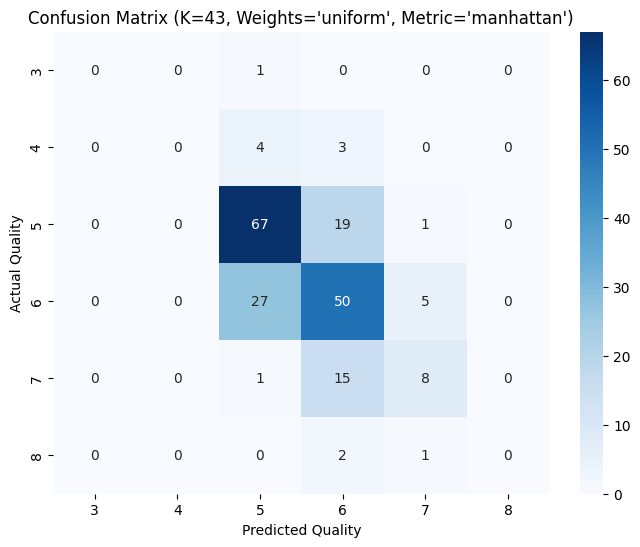

In [ ]:
plt.figure(figsize=(8, 6))
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, best_y_pred, labels=labels)

print(classification_report(y_test, best_y_pred, zero_division=0))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title(f"Confusion Matrix (K={best_params['K']}, Weights='{best_params['Weights']}', Metric='{best_params['Metric']}')")
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.show()

# 5. Analisis



###1.   Pada seluruh kombinasi, nilai K yang sangat kecil (K = 1 dan 3) konsisten menghasilkan performa paling rendah (F1-score 0.46 - 0.48). Ini terjadi karena K kecil sangat sensitif terhadap noise dan variansi lokal pada data. Seiring bertambahnya K, metrik evaluasi secara bertahap naik dan mencapai titik optimal pada rentang K = 29 - 45.
###2.   Pada dataset tabular berdimensi menengah dengan sisa-sisa outlier di beberapa kolom, metrik Manhattan cenderung lebih robust dibanding Euclidean  (L2 Norm) yang memangkatkan selisih jarak sehingga lebih sensitif terhadap pencilan.
###3. Pembobotan distance mampu meningkatkan stabilitas performa pada metrik Euclidean dengan memberi bobot lebih pada tetangga terdekat, namun pembobotan uniform tetap meraih skor tertinggi ketika dikombinasikan dengan metrik Manhattan pada K=43.
###4. Capaian akurasi maksimum yang tertahan di angka 61.27% mencerminkan bias model terhadap kelas mayoritas (kualitas 5 dan 6). Tinggi-rendahnya nilai akurasi ini didominasi oleh ketepatan model menebak kelas mayoritas tersebut, sementara kegagalan memprediksi kelas minoritas (3, 4, dan 8) tersembunyi di balik angka akurasi yang terlihat cukup tinggi.





# 6. Kesimpulan dan Saran

### Eksperimen menunjukkan bahwa konfigurasi KNN terbaik dicapai pada K=43 dengan metrik Manhattan dan pembobotan uniform (Akurasi: 61,27%), di mana nilai K yang lebih besar terbukti efektif menghaluskan decision boundary dan menekan overfitting. Namun, mekanisme majority voting pada KNN menyebabkan model sangat terbias ke kelas mayoritas sehingga gagal memprediksi kelas minoritas (kualitas 3, 4, dan 8). Untuk meningkatkan performa model, diperlukan penanganan imbalanced class pada data train agar model dapat mengenali karakteristik kelas minoritas.